### Project: customer activity & churn prediction using XGBoost

The objective of this project is to engineer a ML model to predict if a customer will have activity (transactions such as deposits) or not (if the customer will churn). The dataset used was taken from Mendeley Data (https://data.mendeley.com/datasets/9j5gcygnwg/1), and represent the records of customers of a US based gambling payments provider. The data represents customer transactions with deposits & withdrawals. The data comes from a casino focused internet gambling brand, and is a time series. For more insights into the data, the paper "Payments transaction data from online casino players and online sports bettors" from Ghaharian, et. al (2023) was also used. The citation of the paper can be found at the end of this introduction.

The project consists of 2 main parts: an EDA followed by FE and modeling. As the objective is to classify customers (Churn or not), XGBoost for classification is used, although some data preprocessing needs to be done in order to use time series data.



Paper: Ghaharian K, Puranik P, Abarbanel B, Taghva K, Kraus SW, Singh A, Feldman A, Bernhard B. Payments transaction data from online casino players and online sports bettors. Data Brief. 2023 Mar 20;48:109077. doi: 10.1016/j.dib.2023.109077. PMID: 37025505; PMCID: PMC10070505.

## EDA

In [5]:
import pandas as pd
import numpy as np
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [6]:
casino = pd.read_csv('Online_casino_DIB.csv')
print('First look at the data:')
print(casino.head())
print('---------------------------------')
print('Data description:')
print(casino.describe())
print('---------------------------------')
print('Data info:')
print(casino.info())


First look at the data:
                 ReqTimeUTC      TransactionType  TransactionAmount    Status  \
0  2019-07-05T05:02:28+0000     LOYALTYCARDDEBIT               10.0  APPROVED   
1  2019-07-05T05:26:00+0000     LOYALTYCARDDEBIT               10.0  APPROVED   
2  2019-07-05T04:54:35+0000  LOYALTYCARDCREDITCL               10.0  APPROVED   
3  2019-07-05T05:02:27+0000  LOYALTYCARDCREDITCL               10.0  APPROVED   
4  2019-07-05T05:25:59+0000  LOYALTYCARDCREDITCL               10.0  APPROVED   

  AccountIdentifier  
0      customer1734  
1      customer1734  
2      customer1734  
3      customer1734  
4      customer1734  
---------------------------------
Data description:
       TransactionAmount
count      138928.000000
mean          103.012203
std           309.778934
min             1.000000
25%            20.000000
50%            35.000000
75%           100.000000
max         15202.000000
---------------------------------
Data info:
<class 'pandas.core.frame.DataFrame

The first transformation is to modify the column ReqTimeUTC, as it needs to be converted to datetime:

In [7]:
casino['ReqTimeUTC'] = pd.to_datetime(casino['ReqTimeUTC'])
casino.dtypes

ReqTimeUTC           datetime64[ns, UTC]
TransactionType                   object
TransactionAmount                float64
Status                            object
AccountIdentifier                 object
dtype: object

Identifying the time range of the data:

In [8]:
casino.describe(exclude='object')

,ReqTimeUTC,TransactionAmount
count,138928,138928.000000
mean,2019-08-23 14:37:01.511898112+00:00,103.012203
min,2019-03-01 08:03:23+00:00,1.000000
25%,2019-05-19 06:27:26.249999872+00:00,20.000000
50%,2019-08-21 13:32:02.500000+00:00,35.000000
75%,2019-11-23 20:28:33.500000+00:00,100.000000
max,2020-03-02 07:47:06+00:00,15202.000000
std,NaN,309.778934


In [9]:
starttime, endtime = casino['ReqTimeUTC'].min(), casino['ReqTimeUTC'].max()
print(f'Start date: {starttime}\nEnd date: {endtime}')


Start date: 2019-03-01 08:03:23+00:00
End date: 2020-03-02 07:47:06+00:00


The date range of the data goes from March 2019 to March 2020. To keep only a year's worth of data, the range will be adjusted so the max date is February 29:

In [10]:
casino = casino[casino['ReqTimeUTC'] < '2020-02-29 00:00:00+00:00'].copy()
starttime, endtime = casino['ReqTimeUTC'].min(), casino['ReqTimeUTC'].max()
print(f'Start date: {starttime}\nEnd date: {endtime}')

Start date: 2019-03-01 08:03:23+00:00
End date: 2020-02-28 23:54:14+00:00


For further exploration into the TransactionType column data, the following function for categorical columns will be used to obtain the descriptive statistics:


Statistics for the column: TransactionType
Number of unique values: 3
Most frequent values:
TransactionType
LOYALTYCARDDEBIT       69795
LOYALTYCARDCREDITCL    64252
LOYALTYCARDCREDIT       3810
Name: count, dtype: int64

Most frequent value: ['LOYALTYCARDDEBIT']


Statistics for the column: Status
Number of unique values: 2
Most frequent values:
Status
APPROVED    132473
DECLINED      5384
Name: count, dtype: int64

Most frequent value: ['APPROVED']


Statistics for the column: AccountIdentifier
Number of unique values: 2351
Most frequent values:
AccountIdentifier
customer10     2294
customer120    2109
customer26     1831
customer21     1763
customer129    1720
Name: count, dtype: int64

Most frequent value: ['customer10']



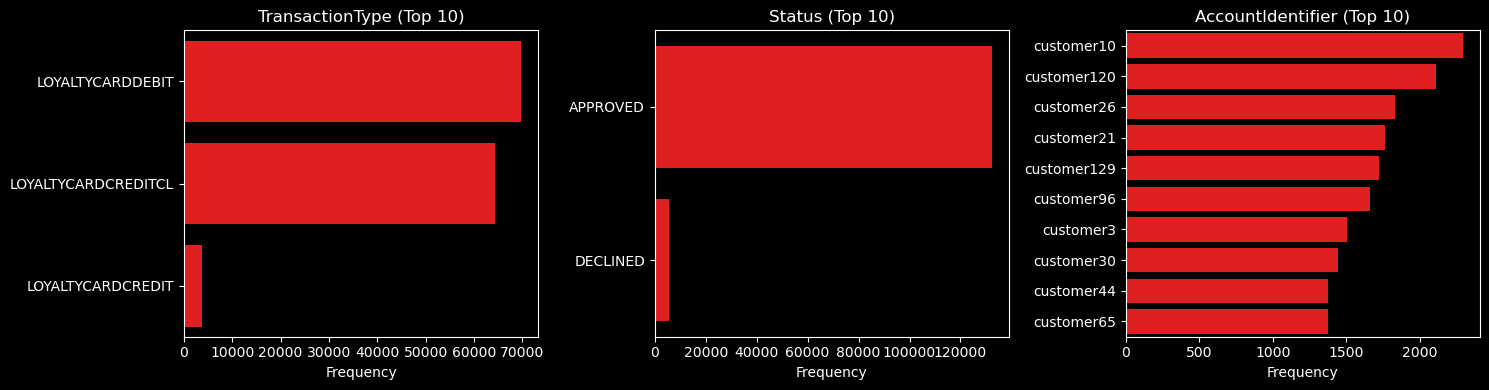

None


In [11]:

def cat_stats(df, columns):
    """
    Function that calculates the descriptive statistics of categorical columns and shows bar charts of the 10 most frequent values in a grid.
    
    Parameters:
    df (DataFrame): The DataFrame containing the data.
    columns (list): List of categorical column names.
    
    Output:
    Prints statistics and shows a grid of bar charts.
    """
    
    # Descriptive statistics
    for column in columns:
        print(f"\nStatistics for the column: {column}")
        print(f"Number of unique values: {df[column].nunique()}")
        print(f"Most frequent values:\n{df[column].value_counts().head(5)}\n")
        print(f"Most frequent value: {list(df[column].mode())}\n")

    # Grid for the graphs
    n_cols = 3 
    n_fil = int(np.ceil(len(columns) / n_cols))

    fig, axes = plt.subplots(n_fil, n_cols, figsize=(5 * n_cols, 4 * n_fil))
    axes = axes.flatten()

    # Bar charts
    for i, column in enumerate(columns):
        ax = axes[i]
        # Filter for only the top 10 most frequent values
        top_10 = df[column].value_counts(dropna=False).nlargest(10)
        if top_10.empty:
            ax.set_visible(False)
            continue

        sns.barplot(x=top_10.values, y=top_10.index, color="red", ax=ax)
        ax.set_title(f"{column} (Top 10)")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("")

    # Hide empty axis
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

print(cat_stats(casino, casino.select_dtypes(include='object').columns))

## Insights

There are 2361 unique customers, of which customer10 is the most present one in the data. It can also be observed that most transaction types are LOYALTYCARDDEBIT and LOYALTYCARDCREDITCL. Based on the paper related to the dataset, the column TransactionType indicates the type of transaction, whith LOYALTYCARDDEBIT as a level 2 deposit, LOYALTYCARDCREDIT as a level 2 withdrawal, and LOYALTYCREDITCL as a level1 deposit mde via card. 

Acording to the paper, level 1 are debits and credits associated with a customer's funding account, like a personal bank account or credit card. Customers can move money freely at level 1 between their personal funding accounts and digital wallets given by the casino. Level 2 are credits and debits associated with the customer's gambling merchant accounts, like an online sports betting account. In here, the money flows between the digital wallet and the wagering account.

Diagram taken from the paper:

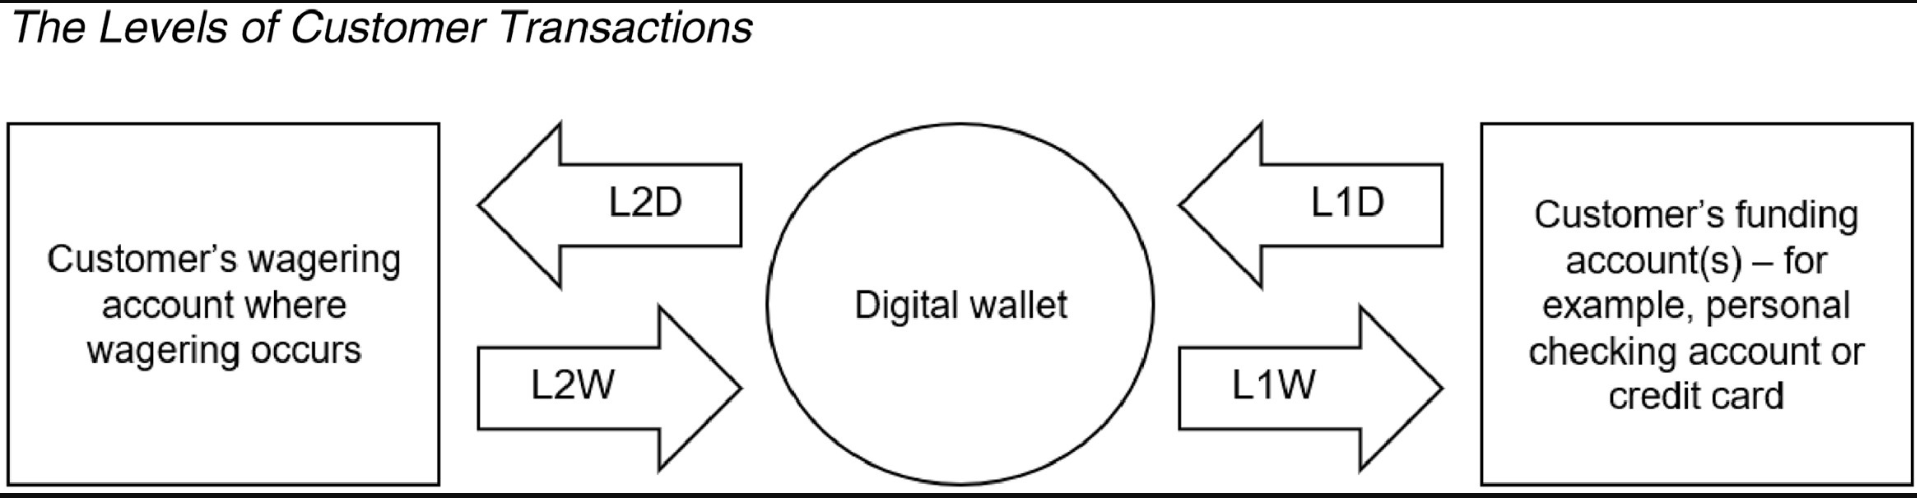

Based on this, the transaction type values can be renamed to more useful ones based on the data description:

In [12]:
casino['TransactionType'] = casino.TransactionType.map({'LOYALTYCARDDEBIT':'L2D','LOYALTYCARDCREDITCL':'L1D','LOYALTYCARDCREDIT':'L2W'})
casino.TransactionType.unique()

array(['L2D', 'L1D', 'L2W'], dtype=object)

Analizying the pattern of the transaction types:

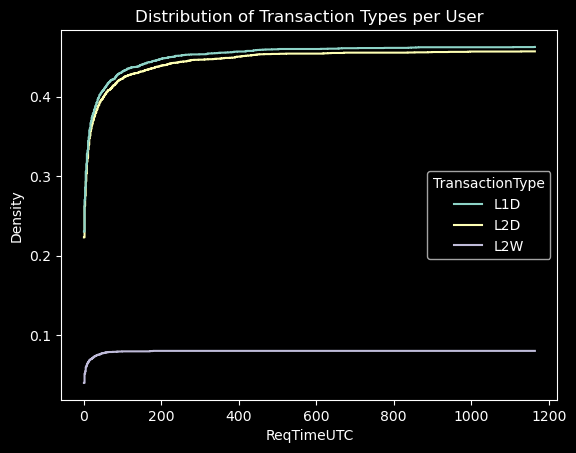

In [13]:
transaction_per_user = casino.groupby(["AccountIdentifier","TransactionType"]).count().reset_index()
sns.histplot(data=transaction_per_user, x="ReqTimeUTC", hue="TransactionType", cumulative=True, stat="density", element="step", fill=False)
plt.title("Distribution of Transaction Types per User")
plt.show()

Based on the cumulative density plot, it can be observed that most customers have a spike in activity at the beginning, while the curve flattens over time. It can also be observed that L1D and L2D have very similar curves, which could indicate that most customers deposit money from their accounts to the digital wallet, and then instantly use it in the wagering account. In contrast, the L2W curve suggests that withdrawals are less frequent and more evenly spread over time.

Now plotting normalizing the time per user to avoid the effect of users that joined at different points in time:

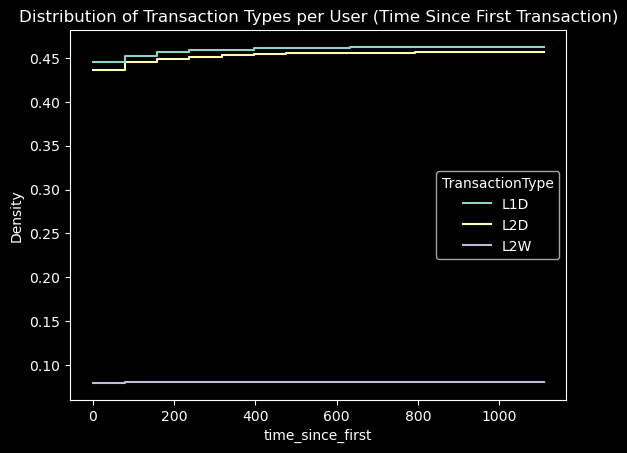

In [14]:
transaction_per_user["time_since_first"] = (
    transaction_per_user.groupby("AccountIdentifier")["ReqTimeUTC"]
    .transform(lambda x: x - x.min())
)
sns.histplot(data=transaction_per_user, x="time_since_first", hue="TransactionType", cumulative=True, stat="density", element="step", fill=False)
plt.title("Distribution of Transaction Types per User (Time Since First Transaction)")
plt.show()

The same behaviour is observed, where users inmediately move their money from their accounts, into their digital wallets, and finally into their wagering accounts. Because of this, for this analysis, the focus will only be on L2D data of approved transactions.


In [15]:
casino = casino[(casino['TransactionType'] == 'L2D') & (casino['Status'] == 'APPROVED')].reset_index(drop=True)
print('New shape of the data:', casino.shape)

New shape of the data: (69734, 5)


The next step is to analyze if the customers that have a high amount of activity are the same ones that introduce large amounts of money into the casino:

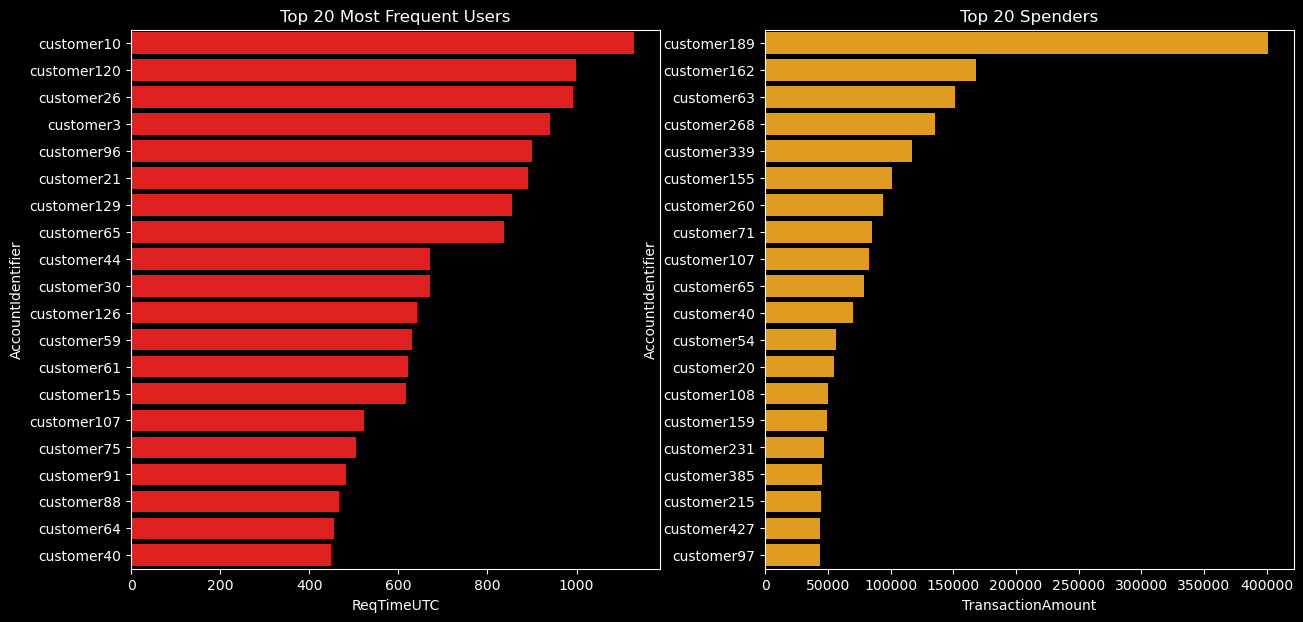

In [16]:
top_20_most_frequent = casino.groupby('AccountIdentifier').count().reset_index().iloc[:,0:2].sort_values(by='ReqTimeUTC', ascending=False)[0:20]
top_20_spenders = casino[["AccountIdentifier","TransactionAmount"]].groupby("AccountIdentifier").sum().reset_index().sort_values("TransactionAmount", ascending=False)[0:20]

fig, ax = plt.subplots(ncols = 2, figsize=(15, 7))

sns.barplot(top_20_most_frequent, x="ReqTimeUTC", y="AccountIdentifier", color="red", ax=ax[0])
sns.barplot(top_20_spenders, x="TransactionAmount", y="AccountIdentifier", color="orange", ax=ax[1])

ax[0].set_title("Top 20 Most Frequent Users")
ax[1].set_title("Top 20 Spenders")

plt.show()

Using the bar charts we can observe that the customers that spend the most are not the same ones that spend the most amount of time gambling in the casino.

Now the datetime column will be decomposed into it's time components to facilitate further analysis:

In [17]:
casino['hour'] = casino.ReqTimeUTC.dt.hour
casino['day_of_week'] = casino.ReqTimeUTC.dt.day_of_week
casino['day_of_week'] = casino['day_of_week'].map({0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'})
casino.head()

,ReqTimeUTC,TransactionType,TransactionAmount,Status,AccountIdentifier,hour,day_of_week
0,2019-07-05 05:02:28+00:00,L2D,10.0,APPROVED,customer1734,5,Friday
1,2019-07-05 05:26:00+00:00,L2D,10.0,APPROVED,customer1734,5,Friday
2,2019-07-05 04:54:37+00:00,L2D,10.0,APPROVED,customer1734,4,Friday
3,2020-02-02 06:50:37+00:00,L2D,50.0,APPROVED,customer935,6,Sunday
4,2019-12-13 12:29:32+00:00,L2D,100.0,APPROVED,customer935,12,Friday


Now that the data is decomposed, the data can be analyzed to look for patterns. Creating a heatmap to see if gambling activity peaks at a certain hour of the day per day:

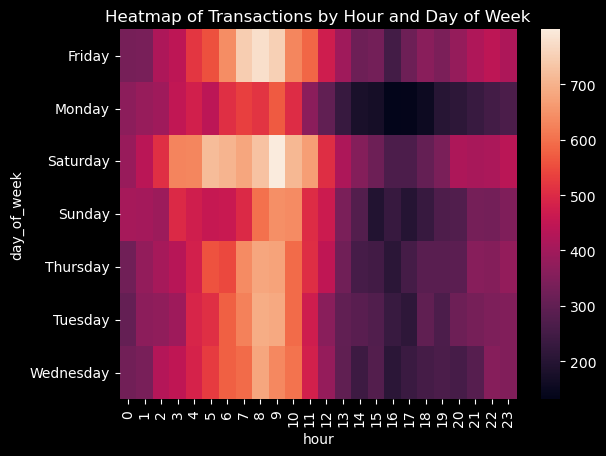

In [18]:
weekly_activity = casino[['hour','day_of_week','TransactionType']].groupby(['hour','day_of_week']).count().reset_index()
weekly_activity_pivot = weekly_activity.pivot(index='day_of_week', columns='hour', values='TransactionType')
sns.heatmap(weekly_activity_pivot)
plt.title("Heatmap of Transactions by Hour and Day of Week")
plt.show()

From the heatmap it can be observed that the days with the most activity are Friday and Saturday. We''l look into daily activity.

In [19]:
# First, extracting the date without time in a separate column
casino['Date'] = casino['ReqTimeUTC'].dt.to_period('D')
daily_activity = casino.groupby(['AccountIdentifier', 'Date']).agg({'TransactionAmount': 'sum','TransactionType':'count'}).reset_index()

C:\Users\diego\AppData\Local\Temp\ipykernel_31596\2862340699.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  casino['Date'] = casino['ReqTimeUTC'].dt.to_period('D')


Now, a dataframe to store the activity per customer for their whole time range of activity is needed:

In [20]:
full_customer_df = pd.DataFrame()

for customer_id in daily_activity.AccountIdentifier.unique():
    
# Getting individual customer ID's
    customer = daily_activity[daily_activity.AccountIdentifier == customer_id]
    
    date_range = pd.period_range(customer['Date'].min(), customer['Date'].max(), freq='D')

# Setting the index to the date and reindexing to fill in missing dates with 0
    customer = customer.set_index(keys = 'Date')

# Filling in missing dates with 0 for TransactionAmount and TransactionType and Accountidentifier with the current customer ID
    customer = customer.reindex(list(date_range), fill_value=0)
    customer['AccountIdentifier'] = [customer_id] * len(customer)
    
# Reseting the index
    customer = customer.reset_index()
    
# Adding the data on each iteration of the loop to the full customer df
    full_customer_df = pd.concat([full_customer_df,customer])
    
full_customer_df = full_customer_df.reset_index(drop=True)
full_customer_df


,Date,AccountIdentifier,TransactionAmount,TransactionType
0,2019-03-01,customer1,120.0,3
1,2019-03-02,customer1,125.0,2
2,2019-03-03,customer1,200.0,2
3,2019-03-04,customer1,160.0,3
4,2019-03-05,customer1,240.0,3
...,...,...,...,...
164651,2019-09-12,customer996,0.0,0
164652,2019-09-13,customer996,25.0,2
164653,2019-09-22,customer997,50.0,1
164654,2019-11-09,customer998,50.0,2


Now we can analyze the flow of customers throughout the year, by visualizing when did they started, when did they left, etc. For this, a Sankey diagram can be used, but first, the data structure needs to be modified:

In [21]:
# Extracting the months as a new column and the number of transactions per customer per month
full_customer_df['Month'] = full_customer_df['Date'].dt.asfreq('M')

customer_month = full_customer_df.groupby(['Month','AccountIdentifier']).count().reset_index().iloc[:,:2]

# Finding out the first and last month of activity for each customer
start = customer_month.groupby('AccountIdentifier').min().reset_index()
end = customer_month.groupby('AccountIdentifier').max().reset_index()

# Merging the start and end dataframes to have the first and last month of activity for each customer in the same row
start_end_df = pd.merge(start,end, on = 'AccountIdentifier')
print(start_end_df.head())

# Finding out the number of customers that started and ended their activity in each month
source_target_value = start_end_df.groupby(['Month_x','Month_y']).count().reset_index()
print(source_target_value.head())

  AccountIdentifier  Month_x  Month_y
0         customer1  2019-03  2020-02
1        customer10  2019-03  2020-02
2       customer100  2019-06  2020-02
3      customer1000  2019-05  2019-05
4      customer1001  2019-07  2020-02
   Month_x  Month_y  AccountIdentifier
0  2019-03  2019-03                276
1  2019-03  2019-04                 58
2  2019-03  2019-05                 49
3  2019-03  2019-06                 33
4  2019-03  2019-07                 27


In [22]:
# Encoding the date columns to be able to use them in the diagram
le = LabelEncoder()
le.fit(source_target_value.Month_x.unique())


LabelEncoder()

In [23]:
# Diagram
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = [str(c) for c in le.classes_],
      color = "blue"
    ),
    link = dict(
      source = le.transform(source_target_value['Month_x']).tolist(),
      target = le.transform(source_target_value['Month_y']).tolist(),
      value = source_target_value['AccountIdentifier'].tolist(),
      hovercolor = ['midnightblue']
  ))])

fig.update_layout(title_text="Customer Activity Flow", font_size=10)
fig.show()


From the diagram, it can be observed that there is a high churn rate due to the size of the nodes, indicating that there is a large portion of one time users. Overlapping lines also show customers starting and ending at different points, with no clear retention pattern. This indicates that the business makes a significant acquisition of customers per month, but has a retention issue.

In [24]:
# Exctracting the data from fast quitters
fast_quitters = source_target_value[source_target_value.Month_x == source_target_value.Month_y]

# Filtering out the fats quitters
source_target_value = source_target_value[source_target_value.Month_x != source_target_value.Month_y]

# running the diagram again without the fast quitters
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = [str(c) for c in le.classes_],
      color = "blue"
    ),
    link = dict(
      source = le.transform(source_target_value['Month_x']).tolist(),
      target = le.transform(source_target_value['Month_y']).tolist(),
      value = source_target_value['AccountIdentifier'].tolist(),
      hovercolor = ['midnightblue']
  ))])

fig.update_layout(title_text="Customer Activity Flow", font_size=10)
fig.show()


By filtering out the one time customers, it can be observed that there is a core loyal customer base that stayed active throughout the year. It can also be observed that most customers churn after a few months. So there is a pattern that customers either become long term, or have a high churn rate.

For further insights, the number of customers per month & one time users can be analyzed:

In [25]:
customers_per_month = customer_month.groupby('Month').count().reset_index()
one_time_customers = fast_quitters[['Month_x','AccountIdentifier']]

# Merging the dataframes to have the number of customers per month and the number of one-time customers per month in the same row
total_customers = pd.merge(customers_per_month, one_time_customers, right_on = 'Month_x', left_on = 'Month')[['Month','AccountIdentifier_x','AccountIdentifier_y']]
total_customers

,Month,AccountIdentifier_x,AccountIdentifier_y
0,2019-03,743,276
1,2019-04,672,92
2,2019-05,699,105
3,2019-06,669,82
4,2019-07,660,94
5,2019-08,624,80
6,2019-09,594,70
7,2019-10,572,62
8,2019-11,555,65
9,2019-12,563,87


Now creating a bar chart to better visualize the data:

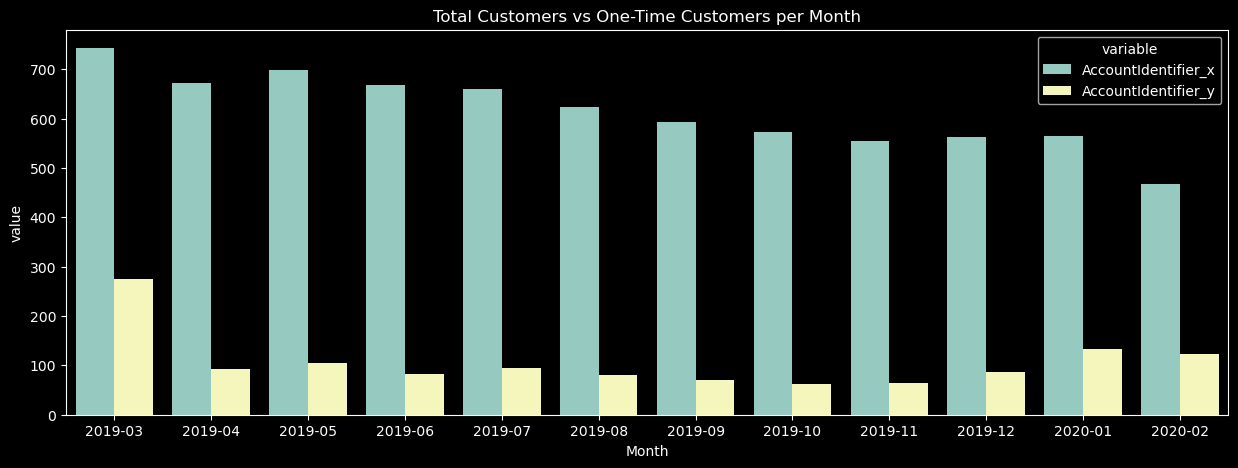

In [26]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(total_customers.melt(id_vars='Month'), x='Month', y='value', hue='variable', ax=ax)
plt.title("Total Customers vs One-Time Customers per Month")
plt.show()

It can be observed that the custimer base is slowly decreasing over time, and that the number of one time customers stay relatively constant each month. 

Now, the data needs the appropiate preprocessing and FE.

### Part 2: FE and model

In [27]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

First, cleaning up the df with only the data that will be used

In [28]:
casino_model = pd.read_csv('Online_casino_DIB.csv')

# Removing timestamps outside of range
casino_model = casino_model[casino_model['ReqTimeUTC'] < '2020-02-29 00:00:00+00:00'].copy()

# Mapping the transaction type values to more understandable ones
casino_model.TransactionType = casino_model.TransactionType.map({'LOYALTYCARDDEBIT':'L2D','LOYALTYCARDCREDITCL':'L1D','LOYALTYCARDCREDIT':'L2W'})

# Filtering to only include L2D transactions with APPROVED status
casino_model = casino_model[(casino_model['TransactionType'] == 'L2D') & (casino_model['Status'] == 'APPROVED')].reset_index(drop=True)

# Removing single value columns
casino_model = casino_model[['AccountIdentifier','ReqTimeUTC','TransactionAmount']]

# Sorting by values
casino_model = casino_model.sort_values(['AccountIdentifier','ReqTimeUTC']).reset_index(drop=True)

# Renaming columns
casino_model.rename(columns = {'AccountIdentifier':'CustomerID','ReqTimeUTC':'Time','TransactionAmount':'Amount'}, inplace = True)
casino_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69734 entries, 0 to 69733
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  69734 non-null  object 
 1   Time        69734 non-null  object 
 2   Amount      69734 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.6+ MB


In [29]:
casino_model.shape

(69734, 3)

First, some questions to frame the problem:

1) How can we identify if a customer will purchase at least once in the next three days?
2) Will a supervised or unsupervised model be needed?
3) Which algorithms are suitable for the problem?
4) Which data do we need?

The data must be aggregated at the day level in order to make predictions at this same level. As we have labels in the data, a supervised model will be used, and we are dealing with a binary classification problem, so we will need a classification algorithm.

The first step is to aggregate the data daily:

In [30]:
# First, removing the time component from the 'Time' column to have only the date
casino_model['Time'] = pd.to_datetime(casino_model['Time']).dt.date
casino_model['day'] = casino_model['Time']

# Grouping by customer and day to get the total amount spent and the number of transactions per day for each customer
daily_activity = casino_model.groupby(['CustomerID','day']).agg({'Amount':['sum','count']}).reset_index()

# Dropping the multiindex created by the aggregation and renaming the columns
daily_activity = daily_activity.droplevel(axis=1, level=1)
daily_activity.columns = ['CustomerID','day','daily_amount','transaction_number']
daily_activity.head()

,CustomerID,day,daily_amount,transaction_number
0,customer1,2019-03-01,120.0,3
1,customer1,2019-03-02,125.0,2
2,customer1,2019-03-03,200.0,2
3,customer1,2019-03-04,160.0,3
4,customer1,2019-03-05,240.0,3


Now, for data consistency, the gaps where customers didn't have any activity need to be filled out:

In [31]:
# df to store the daily activity of all customers, filling in the missing days with 0 for each customer
all_customers_df = pd.DataFrame()
# Looping through each customer
for customer_id in daily_activity.CustomerID.unique():
    customer_df = daily_activity[daily_activity.CustomerID == customer_id]
    # Getting the date range for each customer
    customer_date_range = pd.date_range(
        customer_df.day.min(),
        customer_df.day.max(),
        freq='D'
    )
    
   # Setting the date column as the index
    customer_df = customer_df.set_index(keys = 'day').copy()
    
    # Filling the missing values with 0
    customer_df = customer_df.reindex(list(customer_date_range), fill_value=0).reset_index()
    
    # Filling the missing values in the CustomerID column with the current customer ID
    customer_df['CustomerID'] = [customer_id]*len(customer_df)
    
    # Concatenating the data of each customer to the full customer df
    all_customers_df = pd.concat([all_customers_df, customer_df])

all_customers_df = all_customers_df.reset_index(drop=True)
all_customers_df.head()

,day,CustomerID,daily_amount,transaction_number
0,2019-03-01,customer1,120.0,3
1,2019-03-02,customer1,125.0,2
2,2019-03-03,customer1,200.0,2
3,2019-03-04,customer1,160.0,3
4,2019-03-05,customer1,240.0,3


## Feature engineering

A sliding window of 14 days with a prediction of 3 days after will be used for the model. Also, several new features will be created to improve model performance:

In [32]:
ml_df = pd.DataFrame()

for customer in all_customers_df.CustomerID.unique():
    customer_df = all_customers_df[all_customers_df.CustomerID == customer]
    customer_df = customer_df.sort_values('day').reset_index(drop=True)
    
    features = []
    responses = []
    prediction_dates = []  # Stores the first day of each prediction window
    
    # Initial cutoff indices will be incremented
    x1,x14,y = 0,14,17
    
    while y <= len(customer_df):
        # Extracting the features for the current window (x1 to x14)
        feat_x1_x14 = customer_df.transaction_number[x1:x14].values.tolist()
        
        # Counting non zero transactions in the next 3 days
        next_3_days_transactions = np.count_nonzero(customer_df.transaction_number[x14:y])
        
        # Creating the response variable: 0 if there are transactions in the next 3 days, 1 otherwise
        # This will focus the model on predicting the customers that are likely to quit (no transactions in the next 3 days)
        response = [0 if next_3_days_transactions != 0 else 1][0]
        responses.append(response)
        
        # Storing the prediction start date (first day of the 3-day prediction window)
        prediction_dates.append(customer_df['day'].iloc[x14])
        
        # Additional features
        # Number of days with money deposits in the last 14 days
        x15 = np.count_nonzero(customer_df.transaction_number[x1:x14])
        
        # Number of days with money deposits in the last 7 days
        x16 = np.count_nonzero(customer_df.transaction_number[x14-7:x14])
        
        # Number of days with money deposits in the last 3 days
        x17 = np.count_nonzero(customer_df.transaction_number[x14-2:x14+1])
        
        # Average number of deposits in the last 14 days
        x18 = customer_df.transaction_number[x1:x14].mean().tolist()
        
        # Max number of daily deposits in the last 14 days
        x19 = customer_df.transaction_number[x1:x14].max()
        
        # Amount deposited in the last 7 days
        x20 = customer_df.daily_amount[x14-7:x14].sum().tolist()
        
        # Average daily amount deposited in the last 7 days
        x21 = customer_df.daily_amount[x14-7:x14].mean().tolist()
        
        feat_x1_x14.extend([x15,x16,x17,x18,x19,x20,x21,customer])
        features.append(feat_x1_x14)
        
        # Incrementing the cutoff indices to move the window
        x1 += 1
        x14 += 1
        y += 1
    
    df = pd.DataFrame(features)
    df['response'] = responses
    df['prediction_date'] = prediction_dates  # First day of the 3-day prediction window
    ml_df = pd.concat([ml_df, df])

C:\Users\diego\AppData\Local\Temp\ipykernel_31596\900426619.py:62: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\diego\AppData\Local\Temp\ipykernel_31596\900426619.py:62: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\diego\AppData\Local\Temp\ipykernel_31596\900426619.py:62: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes

In [33]:
ml_df

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,response,prediction_date
0,3.0,2.0,2.0,3.0,3.0,4.0,2.0,2.0,3.0,0.0,...,9.0,2.0,1.0,1.714286,4.0,400.0,57.142857,customer1,0.0,2019-03-15
1,2.0,2.0,3.0,3.0,4.0,2.0,2.0,3.0,0.0,0.0,...,9.0,2.0,2.0,1.714286,4.0,285.0,40.714286,customer1,0.0,2019-03-16
2,2.0,3.0,3.0,4.0,2.0,2.0,3.0,0.0,0.0,0.0,...,9.0,2.0,3.0,1.642857,4.0,110.0,15.714286,customer1,0.0,2019-03-17
3,3.0,3.0,4.0,2.0,2.0,3.0,0.0,0.0,0.0,0.0,...,9.0,3.0,2.0,1.642857,4.0,145.0,20.714286,customer1,1.0,2019-03-18
4,3.0,4.0,2.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,...,8.0,3.0,1.0,1.428571,4.0,145.0,20.714286,customer1,1.0,2019-03-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,customer996,1.0,2019-09-07
164,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,customer996,1.0,2019-09-08
165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,customer996,1.0,2019-09-09
166,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,customer996,1.0,2019-09-10


For the train test split, a split by customer will be used. This will prevent data leakage as there is no customer overlap, and no overlapping windows. This will force the model to generalize across customers.

In [34]:
# First, dropping duplicates from the features except customer ID (the last column) to avoid having the same features with different responses for the same customer, and resetting the index
ml_df = ml_df.drop_duplicates(subset=list(range(20))).reset_index(drop=True)
print('New length of the dataframe after dropping duplicates:', len(ml_df))


New length of the dataframe after dropping duplicates: 54235


In [35]:
# Encoding the response variable
le = LabelEncoder()
ml_df.response = le.fit_transform(ml_df.response)

In [36]:
# Checking the distribution of the response variable
Counter(ml_df.response)

Counter({0: 31534, 1: 22701})

The class distribution is aceptable and doesn't require balancing techniques in this case, so none will be applied.

In [37]:
# Splitting by customer to prevent data leakage
balanced_df = ml_df

# Obtaining only the customer ID and response columns, grouping by customer ID and counting the number of responses for each customer, and resetting the index to have a clean dataframe
split_df = balanced_df.iloc[:,[21,22]].groupby(21).count().reset_index()

# Sampling 20% of the customers to be in the test set and getting their IDs
test_customers = list(split_df.sample(frac=0.2)[21])
test_customers[0:3]

['customer177', 'customer638', 'customer1082']

In [38]:
# Filtering the original dataframe to get the test and train sets based on the sampled customer IDs
test_df = balanced_df[balanced_df[21].isin(test_customers)]
train_df = balanced_df[~balanced_df[21].isin(test_customers)]

print('Train df shape:', train_df.shape)
print('Class balance in train df:', Counter(train_df.response))
print('Test df shape:', test_df.shape)
print('Class balance in test df:', Counter(test_df.response))

Train df shape: (45256, 24)
Class balance in train df: Counter({0: 26452, 1: 18804})
Test df shape: (8979, 24)
Class balance in test df: Counter({0: 5082, 1: 3897})


In [39]:
# Making the training and testing sets by separating the features (the first 21 columns) from the response variable (the last column)
x_train = train_df.iloc[:, :21]
y_train = train_df.response

x_test = test_df.iloc[:, :21]
y_test = test_df.response

## Model: XGBoost with Time Series Cross-Validation

Standard k-fold CV randomly shuffles rows, which for this dataset means future windows could land in training and past windows in validation, resulting in a form of temporal leakage. Since the features are built from sliding windows over time, the CV strategy must also respect temporal ordering.

Using TimeSeriesSplit solves this issue by creating sequential folds where each training set always precedes its validation set in time, mimicking how the model would be used in production.

The training data is sorted by prediction_date before fitting so the splits align correctly across all customers.

In [40]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Sort training data chronologically so TimeSeriesSplit folds respect temporal ordering.
# Without this sort, rows are ordered by customer rather than by date, and the splits
# would not correctly separate past from future.
train_sorted = train_df.sort_values('prediction_date').reset_index(drop=True)
x_train_sorted = train_sorted.iloc[:, :21]
y_train_sorted = train_sorted['response']

# TimeSeriesSplit: training data always comes before validation data in time
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [50, 100, 200, 300],        
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.3],      
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0.1, 1]                  
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train_sorted, y_train_sorted)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation F1 score:', grid_search.best_score_)
print('Test set F1 score:', grid_search.best_estimator_.score(x_test, y_test))

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.8}
Best cross-validation F1 score: 0.7699804964573307
Test set F1 score: 0.787949660318521


Now, let's visualize the results of the model with the best parameters:

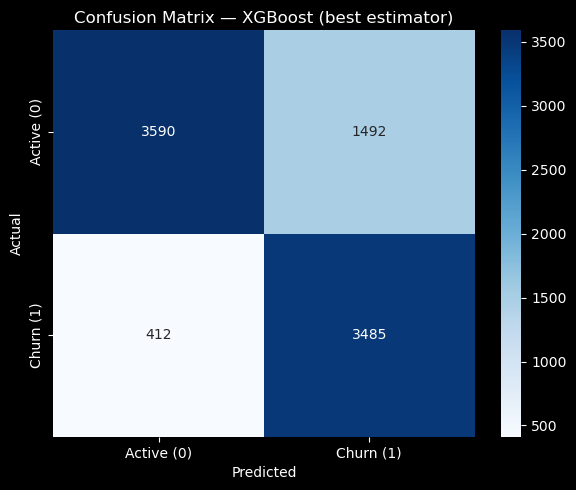

              precision    recall  f1-score   support

  Active (0)       0.90      0.71      0.79      5082
   Churn (1)       0.70      0.89      0.79      3897

    accuracy                           0.79      8979
   macro avg       0.80      0.80      0.79      8979
weighted avg       0.81      0.79      0.79      8979



In [41]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = grid_search.best_estimator_.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Active (0)', 'Churn (1)'],
    yticklabels=['Active (0)', 'Churn (1)'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — XGBoost (best estimator)')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Active (0)', 'Churn (1)']))

In [42]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

tn, fp, fn, tp = cm.ravel()

print(f"\n  Best CV parameters:  {grid_search.best_params_}")
print(f"  Best CV F1 score:    {grid_search.best_score_:.3f}")
print()
print(f"  {'Metric':<30} {'Value':>6}")
print(f"  {'-'*37}")
print(f"  {'Accuracy':<30} {accuracy_score(y_test, y_pred):>6.3f}")
print(f"  {'Churn precision':<30} {precision_score(y_test, y_pred):>6.3f}")
print(f"  {'Churn recall':<30} {recall_score(y_test, y_pred):>6.3f}")
print(f"  {'Churn F1':<30} {f1_score(y_test, y_pred):>6.3f}")
print(f"  {'Macro F1':<30} {f1_score(y_test, y_pred, average='macro'):>6.3f}")
print()
print(f"  True churners caught (TP):   {tp:>5}")
print(f"  Churners missed    (FN):      {fn:>5}  ← customers we'd lose")
print(f"  False alarms       (FP):      {fp:>5}  ← wasted retention offers")
print(f"  Correctly inactive (TN):      {tn:>5}")


  Best CV parameters:  {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.8}
  Best CV F1 score:    0.770

  Metric                          Value
  -------------------------------------
  Accuracy                        0.788
  Churn precision                 0.700
  Churn recall                    0.894
  Churn F1                        0.785
  Macro F1                        0.788

  True churners caught (TP):    3485
  Churners missed    (FN):        412  ← customers we'd lose
  False alarms       (FP):       1492  ← wasted retention offers
  Correctly inactive (TN):       3590


### Threshold tuning

By default, XGBoost predicts class 1 (churn) whenever the estimated probability exceeds 0.5. Raising this threshold reduces false positives (active customers wrongly flagged as churners) at the cost of missing some true churners. The precision-recall curve below shows the full trade-off so we can pick a threshold intentionally.

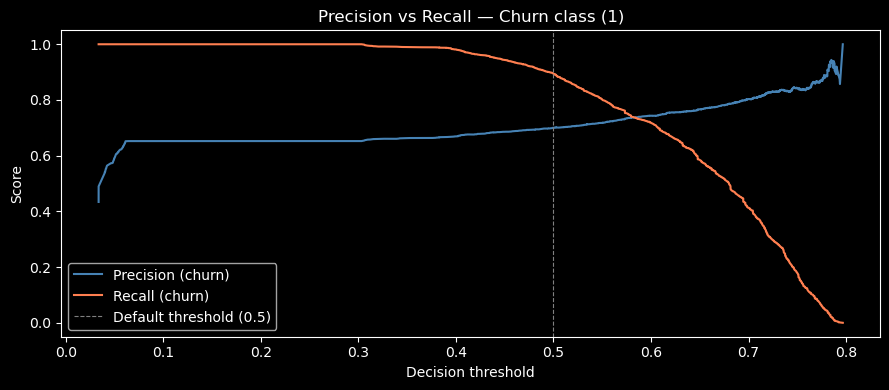

In [43]:
from sklearn.metrics import precision_recall_curve

# Probability of the positive class (churn = 1) for each test sample
y_proba = grid_search.best_estimator_.predict_proba(x_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions[:-1], label='Precision (churn)', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall (churn)', color='coral')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, label='Default threshold (0.5)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall — Churn class (1)')
ax.legend()
plt.tight_layout()
plt.show()

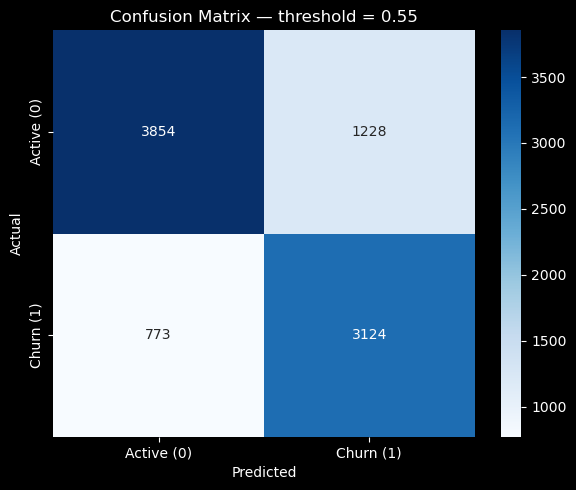

              precision    recall  f1-score   support

  Active (0)       0.83      0.76      0.79      5082
   Churn (1)       0.72      0.80      0.76      3897

    accuracy                           0.78      8979
   macro avg       0.78      0.78      0.78      8979
weighted avg       0.78      0.78      0.78      8979



In [44]:
# Apply a custom threshold — adjust this value based on the curve above
threshold = 0.55

y_pred_tuned = (y_proba >= threshold).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Active (0)', 'Churn (1)'],
    yticklabels=['Active (0)', 'Churn (1)'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — threshold = {threshold}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_tuned, target_names=['Active (0)', 'Churn (1)']))

### Conclusions

The EDA revealed that the casino sufers from a customer retention problem, as there are a high amount of one time customers per month and also, it can be observed that the customer count decreases over time. Even though most of the transactions are deposits, the high churn rate limits the business potential. The model achieved an overall good score and balance between precision and recall for the churn class, and it was identified that raising the decision threshold above the default 0.5 reduced false positives, but it also doubled the number of false negatives, so it is not a desirable trade off.

The model enables proactive churn intervention for customers flagged as likely to churn 3 days in advance so that they can be targeted wit retention methods such as offers, incentives, customized marketing & ads, etc. 

For further study, more classification ML models could be implemented in the future to compare against XGBoost. and also implementing class balancing techniques such as SMOTE to further optimize the model's performance